# TP – Álgebra Lineal Computacional  
### Universidad de Buenos Aires
### Facultad de Ciencias Exactas y Naturales
### Red Neuronal Lineal
##### Nombres:
###### Barello Renata - 1060/24
###### González Frey Paloma - 1030/24
###### Flores García Emanuel - 820/24
###### Fiorini Catalina - 904/24
---


#### Introducción

En este trabajo se comparan cuatro metodologías para obtener el **vector de pesos W** en un problema de **clasificación binaria**: *Householder (HH)*, *Gram-Schmidt (GS)*, *Ecuaciones Normales (EN)* y la *Descomposición en Valores Singulares (SVD)*. Todas estas técnicas provienen de la misma formulación de mínimos cuadrados, pero difieren en la manera en que construyen la pseudo-inversa de X, la base ortonormal o resuelven el sistema, lo que puede generar variaciones en su desempeño numérico. La implementación de las mismas están detalladas en el archivo 'alc.py' adjunto.

El objetivo es evaluar cómo cada método clasifica las observaciones del conjunto de validación y determinar si existen diferencias relevantes entre ellos. Para esto, se analizan dos tipos de resultados: la **Accuracy**, que mide la proporción total de **aciertos**, y la **matriz de confusión**, que permite observar cómo se distribuyen los errores y si alguna clase es más difícil de predecir.

Este análisis no solo permite identificar si un método obtiene un mejor rendimiento, sino también explorar la estabilidad del problema y la sensibilidad de la solución frente a distintas estrategias de descomposición y resolución. De esta forma, el estudio funciona como un pequeño benchmark que muestra si, en la práctica, estas técnicas teóricamente equivalentes producen resultados similares o si aparecen diferencias significativas que deban tenerse en cuenta en aplicaciones reales.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

Exportamos las variables de nuestro interés que fueron guardadas en el archivo py que nos permitirán realizar la comparación entre los performance.

In [3]:
try:
    
    Xv = np.load('Xv.npy')
    print("Xv cargado.")
    Yv = np.load('Yv.npy')
    print("Yv cargado.")

    y_pred_SVD = np.load('y_pred_SVD.npy')
    print("y_pred_SVD cargado.")
    
    y_pred_HH = np.load('y_pred_HH.npy') 
    print("y_pred_HH cargado.")
    y_pred_GS = np.load('y_pred_GS.npy') 
    print("y_pred_GS cargado.")

    y_pred_EN = np.load('y_pred_cholesky.npy')
    print("y_pred_EN cargado.")
    
    # 3. Y así sucesivamente.
except FileNotFoundError as e:
    # Esto te dirá exactamente qué archivo no se encontró
    print(f"Error al cargar: {e}")

Xv cargado.
Yv cargado.
y_pred_SVD cargado.
y_pred_HH cargado.
y_pred_GS cargado.
y_pred_EN cargado.


A continuación definimos la función para hacer la matriz de confusion desde y_pred (valores predecidos) Yv (valores reales)
   Devuelve una matriz de confusión 2×2 por cada algoritmo, tendrá la forma:


|| Gato | Perro|  
| :--- | :---: | :---: |
|**Gato**| era gato | no era perro | 
|**Perro**| no era gato | era perro | 

In [36]:
def matriz_confusion(Yv, y_pred):
    matriz_confusion = np.array([[0,0], [0,0]])  
    n = y_pred.shape[1]

    for i in range(n):

        # --- Predicción: GATO ---
        if y_pred[0][i] == 1:
            if Yv[0][i] == 1:                  # Real: GATO
                matriz_confusion[0][0] += 1    # TP
            else:                              # Real: PERRO
                matriz_confusion[0][1] += 1    # FP

        # --- Predicción: PERRO ---
        else:
            if Yv[1][i] == 1:                   # Real: PERRO
                matriz_confusion[1][1] += 1     # TN
            else:                               # Real: GATO
                matriz_confusion[1][0] += 1    # FN

    return matriz_confusion
matriz_confusion_SVD = matriz_confusion(y_pred_SVD, Yv)
matriz_confusion_HH = matriz_confusion(y_pred_HH, Yv)
matriz_confusion_GS = matriz_confusion(y_pred_HH, Yv)
matriz_confusion_EN = matriz_confusion(y_pred_EN, Yv)

In [42]:
print('matriz de confusion EN:', matriz_confusion_EN)
print('matriz de confusion GS:', matriz_confusion_GS)
print('matriz de confusion HH', matriz_confusion_HH)
print('matriz de confusion SVD:', matriz_confusion_SVD)

matriz de confusion EN: [[334 166]
 [150 350]]
matriz de confusion GS: [[334 166]
 [150 350]]
matriz de confusion HH [[334 166]
 [150 350]]
matriz de confusion SVD: [[333 167]
 [150 350]]


Graficamos las matrices recién obtenidas.

In [7]:
def plot_confusion_matrix(cm, title, labels=['Gato (Pred)', 'Perro (Pred)']):
    """
    Genera un mapa de calor para la matriz de confusión.
    """
    plt.figure(figsize=(6, 5))
    
    # Crea el mapa de calor
    sns.heatmap(cm, 
                annot=True,              # Mostrar los valores numéricos
                fmt='d',                 # Formato para números enteros
                cmap='Blues',            # Esquema de color
                cbar=False,              # Ocultar la barra de color lateral
                linewidths=.5,           # Líneas entre celdas
                linecolor='black')

    # Configura las etiquetas
    plt.xlabel('Etiqueta REAL', fontsize=12)
    plt.ylabel('Predicción', fontsize=12)
    plt.xticks([0.5, 1.5], labels=['Gato', 'Perro'])
    plt.yticks([0.5, 1.5], labels=['Gato', 'Perro'], rotation=0)
    
    # Título y mostrar
    plt.title(f'Matriz de Confusión: {title}', fontsize=14)
    plt.show()

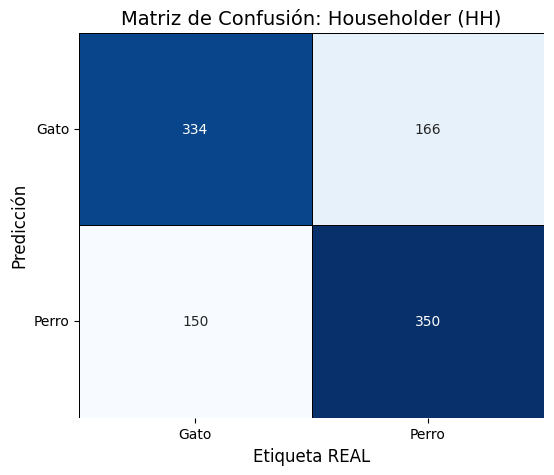

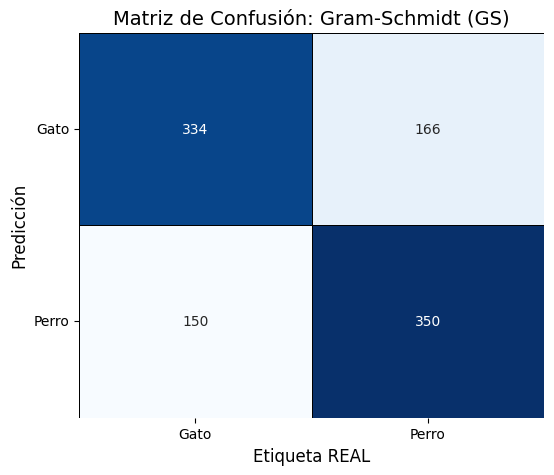

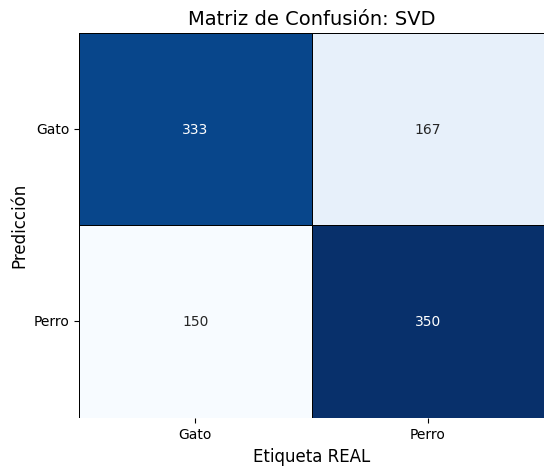

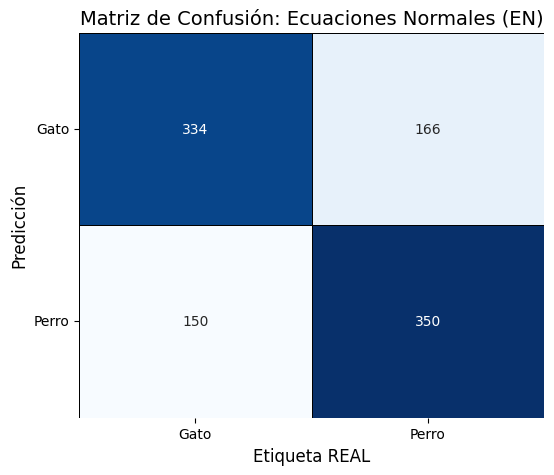

In [38]:
# Graficar Householder (HH)
plot_confusion_matrix(matriz_confusion_HH, title="Householder (HH)")

# Graficar Gram-Schmidt (GS)
plot_confusion_matrix(matriz_confusion_GS, title="Gram-Schmidt (GS)")

# Graficar SVD 
plot_confusion_matrix(matriz_confusion_SVD, title="SVD")

# Graficar Ecuaciones Normales (EN)
plot_confusion_matrix(matriz_confusion_EN, title="Ecuaciones Normales (EN)")

Calclamos ahora el accuracy de cada una, para tener otra herramienta visual.

In [39]:
def calcular_accuracy(cm):
    """Calcula la exactitud a partir de la matriz de confusión."""
    TP, FP = cm[0, 0], cm[0, 1]
    FN, TN = cm[1, 0], cm[1, 1]
    
    total = TP + FP + FN + TN
    if total == 0:
        return 0
    return (TP + TN) / total

# Calcula el Accuracy para cada método
accuracy_hh = calcular_accuracy(matriz_confusion_HH)
accuracy_gs = calcular_accuracy(matriz_confusion_GS)
accuracy_svd = calcular_accuracy(matriz_confusion_SVD)
accuracy_en = calcular_accuracy(matriz_confusion_EN)


print(f"Accuracy HH: {accuracy_hh:.4f}")
print(f"Accuracy GS: {accuracy_gs:.4f}")
print(f"Accuracy SVD: {accuracy_svd:.4f}")
print(f"Accuracy EN: {accuracy_en:.4f}")


Accuracy HH: 0.6840
Accuracy GS: 0.6840
Accuracy SVD: 0.6830
Accuracy EN: 0.6840


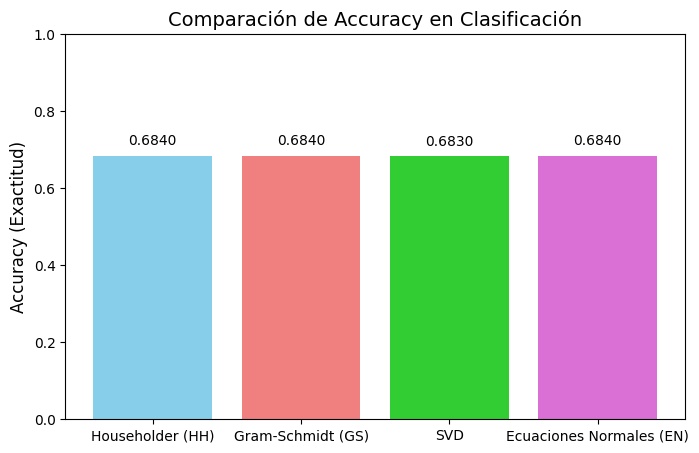

In [41]:
# Crea los datos para el gráfico
metodos = ['Householder (HH)', 'Gram-Schmidt (GS)', 'SVD', 'Ecuaciones Normales (EN)']
accuracies = [accuracy_hh, accuracy_gs, accuracy_svd, accuracy_en]

plt.figure(figsize=(8, 5))
barras = plt.bar(metodos, accuracies, color=['skyblue', 'lightcoral', 'limegreen', 'orchid'])

# Etiquetas y Título
plt.ylim(0,1 ) # Escala de 0 a 1 para Accuracy
plt.ylabel('Accuracy (Exactitud)', fontsize=12)
plt.title('Comparación de Accuracy en Clasificación', fontsize=14)

# Mostrar el valor exacto sobre cada barra
for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, 
             f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

plt.show()

#### Sintesis final

Habiendo obtenido las tablas de resultados de Accuracy y las matrices de confusión para cada metodología de resolución de la matriz $\mathbf{W}$, se procede a analizar la performance de cada algoritmo y las sutiles diferencias encontradas.
- Desempeño General y Empate Técnico:
   
   Los resultados de Accuracy global sobre el conjunto de validación (Xv, Yv) son notablemente uniformes: Householder (HH), Gram-Schmidt (GS) y Ecuaciones Normales (EN) obtienen un 0.6840, mientras que la Descomposición SVD logra un 0.6830. Esta agrupación tan cerrada, con una variación de solo $0.001$, indica que la elección del algoritmo de resolución no tiene un impacto significativo en la capacidad predictiva final de la clasificación para este conjunto de datos.
- Análisis  de la Matriz de Confusión:
   
   Podemos entender esta mínima diferencia observando las matrices de confusión, donde se observa un patrón de error casi idéntico en los cuatro métodos. La observación fundamental es la uniformidad de la segunda fila (Real: PERRO). Los 150 Falsos Negativos (FN) y 350 Verdaderos Negativos (TN) son idénticos para las cuatro metodologías. Esto implica que, para la clase "PERRO", la capacidad del modelo de $\mathbf{W}$ para clasificar o fallar es completamente insensible a si se usaron Ecuaciones Normales, QR o SVD.
   La diferencia total en el Accuracy se concentra en la primera fila (Real: GATO):
   EN, GS, HH logran 334 Verdaderos Positivos (TP) y 166 Falsos Positivos (FP).
   SVD logra 333 Verdaderos Positivos (TP) y 167 Falsos Positivos (FP).
   El método SVD falló en clasificar una única instancia más que sus competidores, lo cual explica el descenso de $0.001$ en su rendimiento global.
- Síntesis y Criterios de Elección:
   
   Dado que la Accuracy es prácticamente un empate, la decisión final sobre qué metodología es la "mejor" debe basarse en la robustez numérica y las consideraciones de Benchmarking (tiempo de cómputo):
   - Estabilidad sobre la Performance: El hecho de que las Ecuaciones Normales (EN), conocidas por ser inestables ante matrices mal condicionadas, iguale el rendimiento de Gram-Schmidt (GS) y Householder (HH), sugiere fuertemente que el conjunto de datos de entrenamiento es numéricamente bien condicionado. Sin embargo, en un entorno de producción o con datos nuevos, GS y HH siguen siendo preferibles por su mayor estabilidad inherente.
   - SVD tiene tiempos de cómputo más largos, esta no solo encuentra la solución de mínimos cuadrados, sino que también encuentra la solución que tiene la mínima norma. Es un método robusto aunque esto no siempre maximice las métricas de clasificación.
     
En conclusión, para este problema particular, los métodos de factorización QR (GS y HH) ofrecen el mejor equilibrio, ya que proporcionan la máxima Accuracy posible ($0.6840$) al mismo tiempo que aseguran una mayor estabilidad numérica que el método de Ecuaciones Normales, y un mejor tiempo de cómputo. El rendimiento de SVD, aunque similar, es marginalmente superado en esta métrica de clasificación.

En el caso de querer mejorar el desempeño de la SVD, proponemos utilizar una SVD Truncada como técnica de regularización. La hipótesis es que los valores singulares más pequeños corresponden a ruido o variaciones irrelevantes de las imágenes que no aportan a la clasificación (overfitting) y ensucian la solución de $W$. El experimento para comprobarlo consistiría en realizar un barrido del parámetro $k$ (cantidad de valores singulares retenidos). Calcularíamos $W_k$ utilizando solo los primeros $k$ componentes principales de la descomposición ($k=10, 50, 100, \dots, 1536$) y evaluaríamos la Accuracy en el set de validación para cada caso. Esperamos encontrar un punto óptimo $k < 1536$ donde la Accuracy sea superior a la de la solución de rango completo, demostrando que SVD tiene la ventaja única de poder filtrar ruido espectralmente.